In [2]:
import json
import pandas as pd
from pathlib import Path

LOG_PATH = Path("E5.log")
OUTPUT_PATH = Path("scene_evaluation_responses_E5.csv")

rows = []
with open(LOG_PATH, "r") as f:
    for line in f:
        if "scene_evaluation_completed" in line:
            try:
                # 로그 한 줄에서 JSON 파트 추출
                log_data = json.loads(line.split(" - INFO - ")[1])
                details = log_data["details"]

                scene_id = details["sceneId"]
                system_type = details["systemType"]
                system_name = details["systemName"]
                responses = details["responses"]

                # responses = { "1": "yes", "2": "no", ... }
                for q_id, ans in responses.items():
                    rows.append(
                        {
                            "sceneId": scene_id,
                            "systemType": system_type,
                            "systemName": system_name,
                            "questionId": int(q_id),
                            "answer": ans,
                        }
                    )
            except Exception as e:
                print("Parse error:", e)

# DataFrame으로 변환
df = pd.DataFrame(rows)

# CSV 저장
df.to_csv(OUTPUT_PATH, index=False)

print(f"✅ Saved {len(df)} responses to {OUTPUT_PATH}")
print(df.head(20))

✅ Saved 456 responses to scene_evaluation_responses_E5.csv
    sceneId systemType systemName  questionId answer
0         1    system1   Baseline           1    yes
1         1    system1   Baseline           2     no
2         1    system1   Baseline           3     no
3         1    system1   Baseline           4     no
4         1    system1   Baseline           5    yes
5         1    system1   Baseline           6     no
6         1    system1   Baseline           7    yes
7         1    system1   Baseline           8     no
8         1    system1   Baseline           9    yes
9         1    system1   Baseline          10    yes
10        1    system1   Baseline          11     no
11        1    system1   Baseline          12    yes
12        1    system1   Baseline          13    yes
13        1    system1   Baseline          14    yes
14        1    system1   Baseline          15     no
15        1    system1   Baseline          16    yes
16        1    system1   Baseline       

In [3]:
import pandas as pd
from scipy import stats

# ====== 1) Load + rater 구분 ======
files = {
    # "E1": "scene_evaluation_responses_E1.csv",
    # "E2": "scene_evaluation_responses_E2.csv",
    "E3": "scene_evaluation_responses_E3.csv",
    "E4": "scene_evaluation_responses_E4.csv",
    "E5": "scene_evaluation_responses_E5.csv",
}

dfs = []
for rater, path in files.items():
    df_tmp = pd.read_csv(path)
    df_tmp["rater_id"] = rater
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)

df_filtered = df.copy()

# ====== 3) sceneId × systemType × rater별 yes 비율 ======
yes_ratio_df = (
    df_filtered.groupby(["sceneId", "systemType", "rater_id"])["answer"]
    .apply(lambda x: (x == "yes").mean())
    .reset_index()
    .rename(columns={"answer": "yes_ratio"})
)

# ====== 4) participant_id 매핑 ======
def assign_participant_id(scene_id, system):
    if system == "system1":
        return scene_id
    else:  # system2
        if scene_id <= 6:
            return scene_id + 6
        else:
            return scene_id - 6

yes_ratio_df["participant_id"] = yes_ratio_df.apply(
    lambda r: assign_participant_id(r["sceneId"], r["systemType"]), axis=1
)

# ====== 5) rater별 system1 vs system2 비교 ======
results = {}
for rater, group in yes_ratio_df.groupby("rater_id"):
    pivot_df = group.pivot_table(
        index="participant_id", columns="systemType", values="yes_ratio"
    ).dropna()

    t_stat, p_val = stats.ttest_rel(pivot_df["system1"], pivot_df["system2"])
    results[rater] = {
        "n_pairs": len(pivot_df),
        "t": t_stat,
        "p": p_val,
    }

# ====== 6) 출력 ======
# ====== 6) 출력 ======
for rater, group in yes_ratio_df.groupby("rater_id"):
    pivot_df = group.pivot_table(
        index="participant_id", columns="systemType", values="yes_ratio"
    ).dropna()

    t_stat, p_val = stats.ttest_rel(pivot_df["system1"], pivot_df["system2"])

    mean_std = group.groupby("systemType")["yes_ratio"].agg(["mean", "std"])

    print(f"=== {rater} ===")
    print(f"n={len(pivot_df)}, t={t_stat:.3f}, p={p_val:.4f}")
    print("\n-- Mean / Std by system --")
    print(mean_std)
    print()


=== E3 ===
n=12, t=-0.625, p=0.5446

-- Mean / Std by system --
                mean       std
systemType                    
system1     0.692982  0.132453
system2     0.723684  0.119018

=== E4 ===
n=12, t=-0.072, p=0.9439

-- Mean / Std by system --
                mean       std
systemType                    
system1     0.732456  0.103959
system2     0.736842  0.166436

=== E5 ===
n=12, t=-0.513, p=0.6178

-- Mean / Std by system --
                mean       std
systemType                    
system1     0.793860  0.125873
system2     0.815789  0.096527



In [4]:
yes_ratio_df.to_csv("yes_ratio_by_scene_system_rater.csv", index=False)

In [5]:
# ====== 평가자별 평균 후 참가자 단위 비교 ======
acc_avg = (
    yes_ratio_df
    .groupby(["participant_id", "systemType"])["yes_ratio"]
    .mean()
    .reset_index()
)

pivot_avg = acc_avg.pivot(
    index="participant_id", columns="systemType", values="yes_ratio"
).dropna()

t_stat, p_val = stats.ttest_rel(pivot_avg["system1"], pivot_avg["system2"])

print("=== 평균된 Accuracy per participant ===")
print(pivot_avg)
print(f"\nPaired t-test: t = {t_stat:.3f}, p = {p_val:.4f}")


=== 평균된 Accuracy per participant ===
systemType       system1   system2
participant_id                    
1               0.508772  0.824561
2               0.596491  0.859649
3               0.719298  0.719298
4               0.894737  0.842105
5               0.701754  0.754386
6               0.824561  0.859649
7               0.859649  0.859649
8               0.789474  0.596491
9               0.719298  0.491228
10              0.771930  0.859649
11              0.701754  0.684211
12              0.789474  0.754386

Paired t-test: t = -0.420, p = 0.6824


In [6]:
import pandas as pd
from scipy.stats import wilcoxon

# 1) 참가자×시스템별로 두 평가자 점수 평균(또는 .median())
avg_df = (
    yes_ratio_df
    .groupby(["participant_id", "systemType"])["yes_ratio"]
    .mean()                       # 필요시 .median()으로 교체
    .unstack()                    # columns: system1, system2
    .dropna()                     # 두 시스템 모두 존재하는 참가자만
)

# 2) 대응 Wilcoxon (system1 vs system2)
stat, p = wilcoxon(
    avg_df["system1"], avg_df["system2"],
    zero_method="pratt", alternative="less"
)

print(f"n={len(avg_df)}, Wilcoxon W={stat:.3f}, p={p:.6f}")
print(f"mean(system1)={avg_df['system1'].mean():.3f}, mean(system2)={avg_df['system2'].mean():.3f}")


n=12, Wilcoxon W=32.500, p=0.346827
mean(system1)=0.740, mean(system2)=0.759


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)


In [7]:
import pandas as pd
import statsmodels.formula.api as smf

# yes_ratio_df: [participant_id, systemType, rater_id, yes_ratio]

# 혼합효과 모형: systemType 고정효과 + (participant, rater 랜덤효과)
model = smf.mixedlm(
    "yes_ratio ~ systemType", 
    data=yes_ratio_df,
    groups=yes_ratio_df["participant_id"],
    re_formula="~systemType"
).fit(reml=False)

print(model.summary())


                   Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        yes_ratio
No. Observations:        72             Method:                    ML       
No. Groups:              12             Scale:                     0.0065   
Min. group size:         6              Log-Likelihood:            58.7342  
Max. group size:         6              Converged:                 Yes      
Mean group size:         6.0                                                
----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                          0.740    0.030 24.700 0.000  0.681  0.798
systemType[T.system2]              0.019    0.043  0.439 0.661 -0.066  0.104
Group Var                          0.009    0.061                           
Group x systemType[

/Users/jeongin/Library/Python/3.10/lib/python/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [8]:
import pandas as pd
import numpy as np
from scipy import stats

# 참가자별 system1 vs system2 평균 yes_ratio
avg = (
    yes_ratio_df.groupby(["participant_id","systemType"])["yes_ratio"]
                .mean().unstack().dropna()
)

x = avg["system1"].values
y = avg["system2"].values
diff = y - x

# 1) 평균 차이
mean_diff = diff.mean()

# 2) Cohen's d (paired)
cohens_d = mean_diff / diff.std(ddof=1)

# 3) Cliff's delta
n = len(diff)
n_pos = sum(diff > 0)
n_neg = sum(diff < 0)
cliffs_delta = (n_pos - n_neg) / n

print(f"Mean(system2 - system1) = {mean_diff:.3f}")
print(f"Cohen's d (paired)      = {cohens_d:.3f}")
print(f"Cliff's delta           = {cliffs_delta:.3f}")


Mean(system2 - system1) = 0.019
Cohen's d (paired)      = 0.121
Cliff's delta           = 0.000


In [9]:
import pandas as pd
from scipy.stats import wilcoxon

# --- 1) Set A 질문 매핑 ---
q_to_cat_A = {
  1:"attribute", 2:"attribute", 3:"attribute", 4:"attribute",
  5:"attribute", 6:"attribute", 7:"relation",
  8:"attribute", 9:"attribute", 10:"attribute", 11:"attribute", 12:"relation",
  13:"attribute", 14:"attribute", 15:"attribute", 16:"relation", 17:"relation",
  18:"context", 19:"context"
}

# --- 2) Set B 질문 매핑 ---
q_to_cat_B = {
  1:"attribute", 2:"attribute", 3:"attribute", 4:"attribute", 5:"relation",
  6:"attribute", 7:"attribute", 8:"attribute", 9:"relation", 10:"relation",
  11:"attribute", 12:"attribute", 13:"attribute", 14:"relation",
  15:"attribute", 16:"attribute", 17:"relation", 18:"relation",
  19:"context"
}

# --- 3) sceneId에 따라 카테고리 붙이기 ---
def map_category(row):
    sid, qid = row["sceneId"], row["questionId"]
    if sid <= 6:  # Set A
        return q_to_cat_A.get(qid)
    else:        # Set B
        return q_to_cat_B.get(qid)

df_filtered["category"] = df_filtered.apply(map_category, axis=1)

df_filtered["participant_id"] = df_filtered.apply(
    lambda r: assign_participant_id(r["sceneId"], r["systemType"]), axis=1
)

# --- 4) participant × system × category 평균 yes 비율 ---
cat_ratio_df = (
    df_filtered.groupby(["participant_id","systemType","category"])["answer"]
               .apply(lambda x: (x=="yes").mean())
               .reset_index()
)

# --- 5) category별 Wilcoxon (system1 vs system2) ---
results = []
for cat, g in cat_ratio_df.groupby("category"):
    pivot = g.pivot(index="participant_id", columns="systemType", values="answer").dropna()
    if "system1" in pivot and "system2" in pivot and len(pivot) > 0:
        stat, p = wilcoxon(pivot["system1"], pivot["system2"], zero_method="pratt")
        mean_diff = (pivot["system2"] - pivot["system1"]).mean()
        results.append((cat, len(pivot), mean_diff, stat, p))

print("=== Category-wise comparisons ===")
for cat, n, mean_diff, stat, p in results:
    print(f"{cat}: n={n}, Δ={mean_diff:.3f}, W={stat:.3f}, p={p:.4f}")


=== Category-wise comparisons ===
attribute: n=12, Δ=0.018, W=38.000, p=0.9697
context: n=12, Δ=-0.111, W=18.500, p=0.5647
relation: n=12, Δ=0.051, W=27.000, p=0.3661


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)


In [10]:
# https://www.statsmodels.org/dev/generated/statsmodels.stats.proportion.proportions_ztest.html


In [11]:
import pandas as pd

PATH = "yes_ratio_by_scene_system_rater.csv"

df = pd.read_csv(PATH)

# systemType 별로 yes_ratio
yes_ratio_by_system = df.groupby("systemType")["yes_ratio"].mean()

In [12]:
yes_ratio_by_system

systemType
system1    0.739766
system2    0.758772
Name: yes_ratio, dtype: float64

In [13]:
# 

# ====== 1) Load + rater 구분 ======
files = {
    # "E1": "scene_evaluation_responses_E1.csv",
    # "E2": "scene_evaluation_responses_E2.csv",
    "E3": "scene_evaluation_responses_E3.csv",
    "E4": "scene_evaluation_responses_E4.csv",
    "E5": "scene_evaluation_responses_E5.csv",
}

dfs = []

for rater, path in files.items():
    df_tmp = pd.read_csv(path)
    df_tmp["rater_id"] = rater
    dfs.append(df_tmp)
    
df = pd.concat(dfs, ignore_index=True)

# # Count "yes" per systemType
# count_yes = df[df["answer"] == "yes"].groupby("systemType").size()

df["answer"] = df["answer"].map({"yes": 1, "no": 0})
# df = df[["systemType", "answer"]].value_counts().unstack().fillna(0)

# Run proportions_ztest
from statsmodels.stats.proportion import proportions_ztest
count = df.groupby("systemType")["answer"].sum().values
nobs = df.groupby("systemType")["answer"].count().values
stat, pval = proportions_ztest(count, nobs, alternative='smaller')
print(f"Z-test: stat={stat:.3f}, p={pval:.6f}")

Z-test: stat=-0.811, p=0.208706


In [14]:
df

,sceneId,systemType,systemName,questionId,answer,rater_id
0,1,system1,Baseline,1,1,E3
1,1,system1,Baseline,2,0,E3
2,1,system1,Baseline,3,0,E3
3,1,system1,Baseline,4,1,E3
4,1,system1,Baseline,5,1,E3
...,...,...,...,...,...,...
1363,12,system2,Advanced,15,1,E5
1364,12,system2,Advanced,16,0,E5
1365,12,system2,Advanced,17,1,E5
1366,12,system2,Advanced,18,1,E5


In [12]:
import pandas as pd
from scipy.stats import wilcoxon, rankdata
import numpy as np
import math

def wilcoxon_with_correct_z(x, y=None, alternative='two-sided'):
    """
    올바른 방향성을 가진 z값을 계산하는 Wilcoxon 검정
    """
    # 차이 계산
    if y is not None:
        differences = np.array(y) - np.array(x)  # y - x (두 번째 그룹 - 첫 번째 그룹)
    else:
        differences = np.array(x)
    
    # 0이 아닌 차이만 선택
    non_zero_diffs = differences[differences != 0]
    n = len(non_zero_diffs)
    
    if n == 0:
        return {'W_plus': np.nan, 'W_minus': np.nan, 'W_scipy': np.nan, 
                'z': np.nan, 'p': np.nan, 'n': 0}
    
    # 수동으로 W+ 계산 (양수 차이의 순위 합)
    abs_diffs = np.abs(non_zero_diffs)
    ranks = rankdata(abs_diffs)
    
    # W+ (양수 차이의 순위 합)
    W_plus = np.sum(ranks[non_zero_diffs > 0])
    # W- (음수 차이의 순위 합)  
    W_minus = np.sum(ranks[non_zero_diffs < 0])
    
    # scipy wilcoxon (비교용)
    W_scipy, p = wilcoxon(non_zero_diffs, alternative=alternative)
    
    # 기댓값과 분산
    expected_W = n * (n + 1) / 4
    variance_W = n * (n + 1) * (2 * n + 1) / 24
    
    # W+를 사용한 z값 계산 (방향성 유지)
    if W_plus > expected_W:
        z = (W_plus - 0.5 - expected_W) / math.sqrt(variance_W)
    else:
        z = (W_plus + 0.5 - expected_W) / math.sqrt(variance_W)
    
    return {
        'W_plus': W_plus,
        'W_minus': W_minus, 
        'W_scipy': W_scipy,
        'z': z,
        'p': p,
        'n': n,
        'effect_size_r': abs(z) / math.sqrt(n),
        'mean_diff': np.mean(differences),
        'interpretation': 'Second group > First group' if z > 0 else 'First group > Second group'
    }

# 당신의 데이터로 테스트
baseline = np.array([0.508772, 0.596491, 0.719298, 0.894737, 0.701754, 0.824561, 
                     0.859649, 0.789474, 0.719298, 0.771930, 0.701754, 0.789474])
oopt = np.array([0.859649, 0.596491, 0.491228, 0.859649, 0.684211, 0.754386,
                 0.824561, 0.859649, 0.719298, 0.842105, 0.754386, 0.859649])

print("=== 올바른 Wilcoxon 검정 결과 ===")
result = wilcoxon_with_correct_z(baseline, oopt)

print(f"평균 차이 (OOPT - Baseline): {result['mean_diff']:.6f}")
print(f"W+ (양수 차이의 순위 합): {result['W_plus']}")
print(f"W- (음수 차이의 순위 합): {result['W_minus']}")
print(f"scipy W (min값): {result['W_scipy']}")
print(f"z값: {result['z']:.3f}")
print(f"p값: {result['p']:.4f}")
print(f"유효 표본 수: {result['n']}")
print(f"효과 크기 (r): {result['effect_size_r']:.3f}")
print(f"해석: {result['interpretation']}")

print(f"\n=== 상세 분석 ===")
differences = oopt - baseline
non_zero_diffs = differences[differences != 0]

print(f"전체 차이값:")
for i, diff in enumerate(differences):
    status = "(제외됨)" if diff == 0 else ""
    print(f"  참가자 {i+1}: {diff:.6f} {status}")

print(f"\n0이 아닌 차이값:")
for i, diff in enumerate(non_zero_diffs):
    sign = "양수" if diff > 0 else "음수"
    print(f"  {diff:.6f} ({sign})")

# 순위 계산 과정 보여주기
abs_diffs = np.abs(non_zero_diffs)
ranks = rankdata(abs_diffs)

print(f"\n순위 계산:")
print(f"절댓값: {abs_diffs}")
print(f"순위: {ranks}")

positive_ranks = ranks[non_zero_diffs > 0]
negative_ranks = ranks[non_zero_diffs < 0]

print(f"\n양수 차이의 순위: {positive_ranks} (합: {np.sum(positive_ranks)})")
print(f"음수 차이의 순위: {negative_ranks} (합: {np.sum(negative_ranks)})")

print(f"\n=== 검증 ===")
print(f"W+ + W- = {result['W_plus'] + result['W_minus']} (이론값: {result['n']*(result['n']+1)/2})")
print(f"기댓값: {result['n'] * (result['n'] + 1) / 4}")

# 간단한 사용법도 제공
print(f"\n=== 간단한 사용법 ===")
def simple_wilcoxon_z(group1, group2):
    """간단한 버전"""
    result = wilcoxon_with_correct_z(group1, group2)
    return result['z'], result['p']

z_val, p_val = simple_wilcoxon_z(baseline, oopt)
print(f"z = {z_val:.3f}, p = {p_val:.4f}")

if z_val > 0:
    print("해석: OOPT가 Baseline보다 성능이 좋다")
elif z_val < 0:
    print("해석: Baseline이 OOPT보다 성능이 좋다")
else:
    print("해석: 두 그룹 간 차이가 없다")

=== 올바른 Wilcoxon 검정 결과 ===
평균 차이 (OOPT - Baseline): 0.019006
W+ (양수 차이의 순위 합): 33.5
W- (음수 차이의 순위 합): 21.5
scipy W (min값): 21.5
z값: 0.561
p값: 0.6250
유효 표본 수: 10
효과 크기 (r): 0.177
해석: Second group > First group

=== 상세 분석 ===
전체 차이값:
  참가자 1: 0.350877 
  참가자 2: 0.000000 (제외됨)
  참가자 3: -0.228070 
  참가자 4: -0.035088 
  참가자 5: -0.017543 
  참가자 6: -0.070175 
  참가자 7: -0.035088 
  참가자 8: 0.070175 
  참가자 9: 0.000000 (제외됨)
  참가자 10: 0.070175 
  참가자 11: 0.052632 
  참가자 12: 0.070175 

0이 아닌 차이값:
  0.350877 (양수)
  -0.228070 (음수)
  -0.035088 (음수)
  -0.017543 (음수)
  -0.070175 (음수)
  -0.035088 (음수)
  0.070175 (양수)
  0.070175 (양수)
  0.052632 (양수)
  0.070175 (양수)

순위 계산:
절댓값: [0.350877 0.22807  0.035088 0.017543 0.070175 0.035088 0.070175 0.070175
 0.052632 0.070175]
순위: [10.   9.   2.5  1.   6.5  2.5  6.5  6.5  4.   6.5]

양수 차이의 순위: [10.   6.5  6.5  4.   6.5] (합: 33.5)
음수 차이의 순위: [9.  2.5 1.  6.5 2.5] (합: 21.5)

=== 검증 ===
W+ + W- = 55.0 (이론값: 55.0)
기댓값: 27.5

=== 간단한 사용법 ===
z = 0.561, p = 0.6250
해석:

Z-test: stat=-0.811, p=0.208706


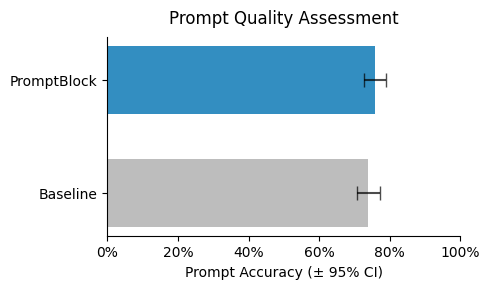

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

# ====== 1) Load + rater 구분 ======
files = {
    "E3": "scene_evaluation_responses_E3.csv",
    "E4": "scene_evaluation_responses_E4.csv",
    "E5": "scene_evaluation_responses_E5.csv",
}

dfs = []
for rater, path in files.items():
    df_tmp = pd.read_csv(path)
    df_tmp["rater_id"] = rater
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)
df["answer"] = df["answer"].map({"yes": 1, "no": 0})

# Calculate proportions
proportions = df.groupby("systemType")["answer"].mean()
counts = df.groupby("systemType")["answer"].sum()
totals = df.groupby("systemType")["answer"].count()

# Run proportions_ztest
count_values = counts.values
nobs_values = totals.values
stat, pval = proportions_ztest(count_values, nobs_values, alternative='smaller')
print(f"Z-test: stat={stat:.3f}, p={pval:.6f}")

# ====== 2) Create horizontal bar chart ======
# Color dictionary
COLOR = {
    "Baseline": "#bdbdbd",  # Blue
    "OOPT": "#0072b2",      # Orange
    "PromptBlock": "#0072b2"  # Same as OOPT
}

def create_proportion_horizontal_barchart(df, title="", xlabel="", figsize=(5, 3)):
    """Proportion 기반 horizontal bar chart with confidence intervals"""
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Calculate proportions and confidence intervals
    systems = df["systemType"].unique()
    proportions = []
    ci_lower = []
    ci_upper = []
    colors = []
    
    for system in systems:
        system_data = df[df["systemType"] == system]["answer"]
        n = len(system_data)
        p = system_data.mean()
        
        # Calculate 95% confidence interval using normal approximation
        se = np.sqrt(p * (1 - p) / n)
        ci_low = p - 1.96 * se
        ci_high = p + 1.96 * se
        
        proportions.append(p)
        ci_lower.append(max(0, ci_low))  # Ensure CI doesn't go below 0
        ci_upper.append(min(1, ci_high))  # Ensure CI doesn't go above 1
        
        # Set color based on system type
        if system == "system1":
            colors.append(COLOR["Baseline"])
        else:
            colors.append(COLOR["OOPT"])
    
    y_pos = np.arange(len(systems))
    
    # Create horizontal bars
    bars = ax.barh(y_pos, proportions, height=0.6)
    
    # Style bars and add labels
    for i, (bar, system) in enumerate(zip(bars, systems)):
        if system == "system1":
            bar.set_facecolor(COLOR["Baseline"])
            bar.set_linewidth(2)
            if i == 0:
                bar.set_label("Baseline")
        else:  # PromptBlock/OOPT
            bar.set_facecolor(COLOR["OOPT"])
            bar.set_alpha(0.8)
            if i == 1:
                bar.set_label("PromptBlock")
    
    # Add error bars for confidence intervals
    xerr_low = [p - ci_l for p, ci_l in zip(proportions, ci_lower)]
    xerr_high = [ci_u - p for p, ci_u in zip(proportions, ci_upper)]
    
    ax.errorbar(proportions, y_pos,
                xerr=[xerr_low, xerr_high],
                fmt='none', ecolor='black', capsize=5,
                linewidth=1.5, alpha=0.7)
    
    # # Add proportion values on bars
    # for i, (p, y) in enumerate(zip(proportions, y_pos)):
    #     ax.text(p + 0.02, y, f'{p:.2%}', 
    #             va='center', fontsize=10, fontweight='bold')
    
    # Set y-axis labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(
        ["Baseline" if s == "system1" else "PromptBlock" for s in systems]
    )
    
    # Set x-axis
    ax.set_xlabel(xlabel if xlabel else "Proportion of 'Yes' Responses (± 95% CI)")
    ax.set_xlim(0, 1)
    
    # Format x-axis as percentage
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
    
    # Add title with z-test results
    if title:
        ax.set_title(f"{title}", 
                    fontsize=12, pad=10)
    
    # Add grid for better readability
    # ax.grid(axis="x", linestyle="--", alpha=0.3)
    
    # Remove top and right spines
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    
    # Add legend
    # ax.legend(loc='lower right', frameon=False)
    
    plt.tight_layout()
    return fig, ax

# Create the chart
fig, ax = create_proportion_horizontal_barchart(
    df,
    title="Prompt Quality Assessment",
    xlabel="Prompt Accuracy (± 95% CI)"
)

# Save the figure
plt.savefig("scene_evaluation_proportions.svg", dpi=300, bbox_inches="tight")
plt.show()

# ====== Alternative: Stacked bar chart for Yes/No counts ======
def create_stacked_horizontal_barchart(df, title="", figsize=(7, 3)):
    """Stacked horizontal bar chart showing Yes/No counts"""
    
    fig, ax = plt.subplots(figsize=figsize)
    
    systems = df["systemType"].unique()
    yes_counts = []
    no_counts = []
    
    for system in systems:
        system_data = df[df["systemType"] == system]["answer"]
        yes_counts.append(system_data.sum())
        no_counts.append(len(system_data) - system_data.sum())
    
    y_pos = np.arange(len(systems))
    
    # Create stacked bars
    bars_yes = ax.barh(y_pos, yes_counts, height=0.6, 
                       color='#70AD47', label='Yes', alpha=0.8)
    bars_no = ax.barh(y_pos, no_counts, height=0.6, left=yes_counts,
                      color='#C5504B', label='No', alpha=0.8)
    
    # Add count labels
    for i, (yes, no) in enumerate(zip(yes_counts, no_counts)):
        total = yes + no
        # Yes label
        if yes > 0:
            ax.text(yes/2, i, f'{yes}\n({yes/total:.1%})', 
                   ha='center', va='center', fontweight='bold', color='white')
        # No label
        if no > 0:
            ax.text(yes + no/2, i, f'{no}\n({no/total:.1%})', 
                   ha='center', va='center', fontweight='bold', color='white')
    
    # Set y-axis labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(
        ["Baseline" if s == "system1" else "PromptBlock" for s in systems]
    )
    
    ax.set_xlabel("Number of Responses")
    ax.set_title(f"{title}\n(Z-test: stat={stat:.3f}, p={pval:.6f})")
    
    # Remove top and right spines
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    
    ax.legend(loc='upper right', frameon=False)
    
    plt.tight_layout()
    return fig, ax

# # Create stacked chart as alternative
# fig2, ax2 = create_stacked_horizontal_barchart(
#     df,
#     title="Scene Evaluation: Response Distribution"
# )

# plt.savefig("scene_evaluation_stacked.svg", dpi=300, bbox_inches="tight")
# plt.show()

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

# ====== 1) Load + rater 구분 ======
files = {
    "E3": "scene_evaluation_responses_E3.csv",
    "E4": "scene_evaluation_responses_E4.csv",
    "E5": "scene_evaluation_responses_E5.csv",
}
dfs = []
for rater, path in files.items():
    df_tmp = pd.read_csv(path)
    df_tmp["rater_id"] = rater
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)
df["answer"] = df["answer"].map({"yes": 1, "no": 0})

# ====== 2) Majority vote ======
# Group by systemType, sceneId, questionId and take majority vote
majority_vote = df.groupby(['systemType', 'sceneId', 'questionId'])['answer'].agg([
    ('sum_votes', 'sum'),          # Total "yes" votes
    ('count_raters', 'count')       # Total number of raters
]).reset_index()

# Majority vote: 1 if more than half voted "yes", 0 otherwise
majority_vote['majority_answer'] = (majority_vote['sum_votes'] > majority_vote['count_raters'] / 2).astype(int)

# Optional: Calculate agreement statistics
majority_vote['agreement_level'] = np.minimum(
    majority_vote['sum_votes'], 
    majority_vote['count_raters'] - majority_vote['sum_votes']
) / majority_vote['count_raters']

majority_vote["answer"] = majority_vote["majority_answer"]
majority_vote

,systemType,sceneId,questionId,sum_votes,count_raters,majority_answer,agreement_level,answer
0,system1,1,1,3,3,1,0.000000,1
1,system1,1,2,0,3,0,0.000000,0
2,system1,1,3,0,3,0,0.000000,0
3,system1,1,4,1,3,0,0.333333,0
4,system1,1,5,3,3,1,0.000000,1
...,...,...,...,...,...,...,...,...
451,system2,12,15,3,3,1,0.000000,1
452,system2,12,16,0,3,0,0.000000,0
453,system2,12,17,3,3,1,0.000000,1
454,system2,12,18,3,3,1,0.000000,1


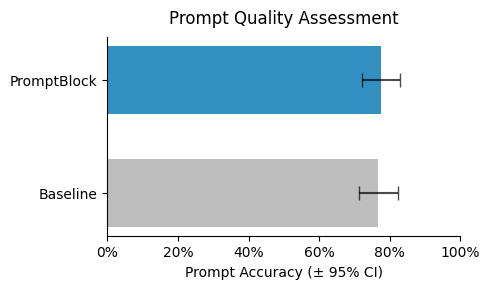

In [11]:
# Create the chart
fig, ax = create_proportion_horizontal_barchart(
    majority_vote,
    title="Prompt Quality Assessment",
    xlabel="Prompt Accuracy (± 95% CI)"
)

# Save the figure
plt.savefig("scene_evaluation_proportions.svg", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# Calculate accuracy per systemType and sceneId

# Calculate accuracy per systemType and sceneId
accuracy_results = majority_vote.groupby(['systemType', 'sceneId']).agg({
    'majority_answer': ['sum', 'count']
}).reset_index()

# Flatten column names
accuracy_results.columns = ['systemType', 'sceneId', 'correct_items', 'total_items']

# Calculate accuracy percentage
accuracy_results['accuracy'] = accuracy_results['correct_items'] / accuracy_results['total_items']

print("Accuracy per systemType and sceneId:")
print(accuracy_results)

# Summary statistics
print(f"\nSummary by systemType:")
summary_by_system = accuracy_results.groupby('systemType')['accuracy'].agg(['mean', 'std', 'count'])
print(summary_by_system)

# Optional: Pivot table for easier viewing
accuracy_pivot = accuracy_results.pivot(index='sceneId', columns='systemType', values='accuracy')
print(f"\nAccuracy pivot table (rows=scenes, cols=systems):")
print(accuracy_pivot)

Accuracy per systemType and sceneId:
   systemType  sceneId  correct_items  total_items  accuracy
0     system1        1             10           19  0.526316
1     system1        2             12           19  0.631579
2     system1        3             14           19  0.736842
3     system1        4             17           19  0.894737
4     system1        5             14           19  0.736842
5     system1        6             16           19  0.842105
6     system1        7             17           19  0.894737
7     system1        8             15           19  0.789474
8     system1        9             14           19  0.736842
9     system1       10             15           19  0.789474
10    system1       11             14           19  0.736842
11    system1       12             17           19  0.894737
12    system2        1             16           19  0.842105
13    system2        2             12           19  0.631579
14    system2        3             10           

In [17]:
baseline, oopt

(sceneId
 1     0.526316
 2     0.631579
 3     0.736842
 4     0.894737
 5     0.736842
 6     0.842105
 7     0.894737
 8     0.789474
 9     0.736842
 10    0.789474
 11    0.736842
 12    0.894737
 Name: system1, dtype: float64,
 sceneId
 1     0.842105
 2     0.631579
 3     0.526316
 4     0.842105
 5     0.684211
 6     0.736842
 7     0.842105
 8     0.894737
 9     0.789474
 10    0.842105
 11    0.789474
 12    0.894737
 Name: system2, dtype: float64)

In [15]:
baseline = accuracy_pivot["system1"]
oopt = accuracy_pivot["system2"]
result = wilcoxon_with_correct_z(baseline, oopt)

print(f"평균 차이 (OOPT - Baseline): {result['mean_diff']:.6f}")
print(f"W+ (양수 차이의 순위 합): {result['W_plus']}")
print(f"W- (음수 차이의 순위 합): {result['W_minus']}")
print(f"scipy W (min값): {result['W_scipy']}")
print(f"z값: {result['z']:.3f}")
print(f"p값: {result['p']:.4f}")
print(f"유효 표본 수: {result['n']}")
print(f"효과 크기 (r): {result['effect_size_r']:.3f}")
print(f"해석: {result['interpretation']}")

print(f"\n=== 상세 분석 ===")
differences = oopt - baseline
non_zero_diffs = differences[differences != 0]

print(f"전체 차이값:")
for i, diff in enumerate(differences):
    status = "(제외됨)" if diff == 0 else ""
    print(f"  참가자 {i+1}: {diff:.6f} {status}")

print(f"\n0이 아닌 차이값:")
for i, diff in enumerate(non_zero_diffs):
    sign = "양수" if diff > 0 else "음수"
    print(f"  {diff:.6f} ({sign})")

# 순위 계산 과정 보여주기
abs_diffs = np.abs(non_zero_diffs)
ranks = rankdata(abs_diffs)

print(f"\n순위 계산:")
print(f"절댓값: {abs_diffs}")
print(f"순위: {ranks}")

positive_ranks = ranks[non_zero_diffs > 0]
negative_ranks = ranks[non_zero_diffs < 0]

print(f"\n양수 차이의 순위: {positive_ranks} (합: {np.sum(positive_ranks)})")
print(f"음수 차이의 순위: {negative_ranks} (합: {np.sum(negative_ranks)})")

print(f"\n=== 검증 ===")
print(f"W+ + W- = {result['W_plus'] + result['W_minus']} (이론값: {result['n']*(result['n']+1)/2})")
print(f"기댓값: {result['n'] * (result['n'] + 1) / 4}")

# 간단한 사용법도 제공
print(f"\n=== 간단한 사용법 ===")
def simple_wilcoxon_z(group1, group2):
    """간단한 버전"""
    result = wilcoxon_with_correct_z(group1, group2)
    return result['z'], result['p']

z_val, p_val = simple_wilcoxon_z(baseline, oopt)
print(f"z = {z_val:.3f}, p = {p_val:.4f}")

if z_val > 0:
    print("해석: OOPT가 Baseline보다 성능이 좋다")
elif z_val < 0:
    print("해석: Baseline이 OOPT보다 성능이 좋다")
else:
    print("해석: 두 그룹 간 차이가 없다")

평균 차이 (OOPT - Baseline): 0.008772
W+ (양수 차이의 순위 합): 28.0
W- (음수 차이의 순위 합): 27.0
scipy W (min값): 27.0
z값: 0.000
p값: 1.0000
유효 표본 수: 10
효과 크기 (r): 0.000
해석: First group > Second group

=== 상세 분석 ===
전체 차이값:
  참가자 1: 0.315789 
  참가자 2: 0.000000 (제외됨)
  참가자 3: -0.210526 
  참가자 4: -0.052632 
  참가자 5: -0.052632 
  참가자 6: -0.105263 
  참가자 7: -0.052632 
  참가자 8: 0.105263 
  참가자 9: 0.052632 
  참가자 10: 0.052632 
  참가자 11: 0.052632 
  참가자 12: 0.000000 (제외됨)

0이 아닌 차이값:
  0.315789 (양수)
  -0.210526 (음수)
  -0.052632 (음수)
  -0.052632 (음수)
  -0.105263 (음수)
  -0.052632 (음수)
  0.105263 (양수)
  0.052632 (양수)
  0.052632 (양수)
  0.052632 (양수)

순위 계산:
절댓값: sceneId
1     0.315789
3     0.210526
4     0.052632
5     0.052632
6     0.105263
7     0.052632
8     0.105263
9     0.052632
10    0.052632
11    0.052632
dtype: float64
순위: [10.   9.   4.5  1.5  7.5  4.5  7.5  4.5  1.5  4.5]

양수 차이의 순위: [10.   7.5  4.5  1.5  4.5] (합: 28.0)
음수 차이의 순위: [9.  4.5 1.5 7.5 4.5] (합: 27.0)

=== 검증 ===
W+ + W- = 55.0 (이론값: 55.0)